In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
class PherhulstModel:
    def __init__(self, N0, Nmax, r):
        self.N0 = N0
        self.Nmax = Nmax
        self.r = r
    
    def run(self, t):
        N = self.Nmax*self.N0*np.exp(self.r*t) / (self.Nmax - self.N0*(1 - np.exp(self.r*t)))
        return N

class GompertzModel:
    def __init__(self, N0, Nmax, r):
        self.N0 = N0
        self.Nmax = Nmax
        self.r = r

    def run(self, t):
        N = self.Nmax*np.pow(self.N0/self.Nmax, np.exp(-self.r*t))
        return N

In [8]:
class Result:
    def __init__(self, t, N):
        self.t = t
        self.N = N

In [87]:
def plot_graphs(results, Nmax, label=None, xlabel = None, ylabel = None):
    for key, res in results.items():
        plt.plot(res.t, res.N, label=key)
    plt.axhline(y=Nmax, linestyle='--', color='red', label="$N_{max}$")
    plt.grid()
    plt.legend()
    if not(label is None):
        plt.title(label)
    if not(xlabel is None):
        plt.xlabel(xlabel)
    if not(ylabel is None):
        plt.ylabel(ylabel)

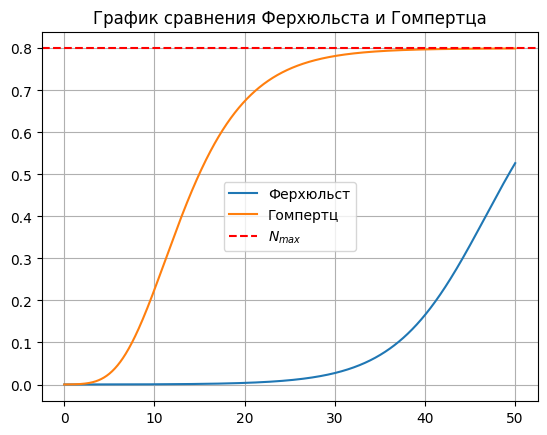

In [85]:
t = np.linspace(0, 50, 1000)
N0, Nmax, r = 7*1e-5, 0.8, 0.2
pher = PherhulstModel(N0, Nmax, r)
gomp = GompertzModel(N0, Nmax, r)

results = {
    "Ферхюльст": Result(t, pher.run(t)),
    "Гомпертц": Result(t, gomp.run(t))
}
plot_graphs(results, Nmax, "График сравнения Ферхюльста и Гомпертца")

In [12]:
class DelayModel:
    def __init__(self, N0, Nmax, r, ts):
        self.N = [N0]
        self.Nmax = Nmax
        self.r = r
        self.ts = ts
    
    def find_near(self, dt):
        a = int(self.ts / dt)
        return self.N[max(len(self.N) - 1 - a, 0)]

    def forward(self, dt):
        dN = self.r * self.N[-1] * (1 - self.find_near(dt)/self.Nmax)
        self.N.append(self.N[-1] + dN * dt)

    def run(self, t):
        dt = t[1] - t[0]
        for i in t[1:]:
            self.forward(dt)
        return self.N

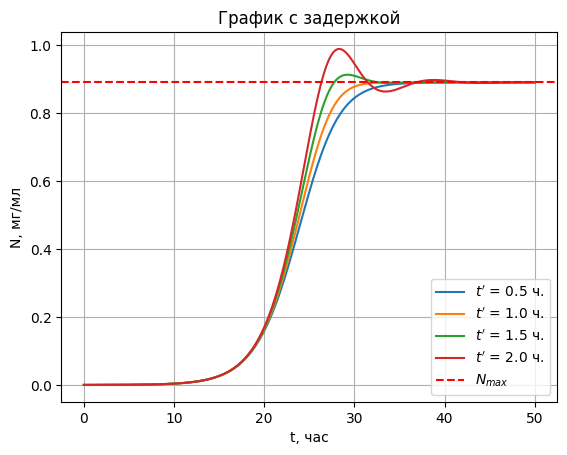

In [88]:
t = np.linspace(0, 50, 1000)
N0, Nmax, r = 7.9793*1e-5, 0.8906, 0.3916
results = {}
for i in [0.5, 1.0, 1.5, 2.0]:
    results[f"$t'$ = {i} ч."] = Result(t, DelayModel(N0, Nmax, r, i).run(t))
plot_graphs(results, Nmax, "График с задержкой", "t, час", "N, мг/мл")

In [14]:
class ModifiedModel:
    def __init__(self, N0, Nmax, r, ts, nu, f, A, tk):
        self.N = [N0]
        self.Nmax = Nmax
        self.r = r
        self.ts = ts
        self.nu = nu
        self.f = f
        self.A = A
        self.tk = tk
    
    def find_near(self, dt):
        a = int(self.ts / dt)
        return self.N[max(len(self.N) - 1 - a, 0)]
    
    def antibio(self, ti):
        sum = 0
        for tk in self.tk:
            if tk > ti:
                continue
            sum += self.nu/self.f(ti) * self.N[-1]*self.A(ti - tk)
        return sum

    def forward(self, dt, ti):
        dN = self.r * self.N[-1] * (1 - self.find_near(dt)/self.Nmax) - self.antibio(ti)
        self.N.append(self.N[-1] + dN * dt)

    def run(self, t):
        dt = t[1] - t[0]
        for i in t[1:]:
            self.forward(dt, i)
        return self.N

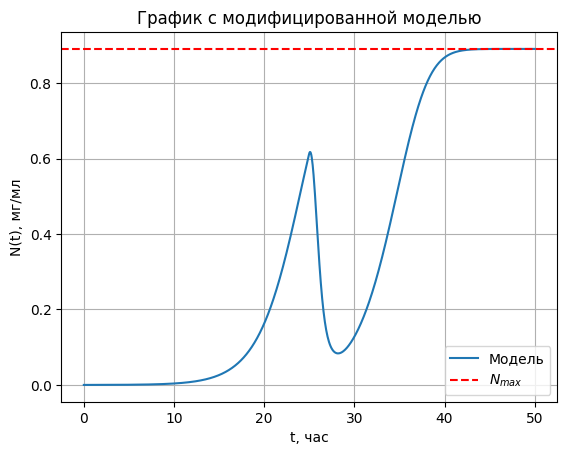

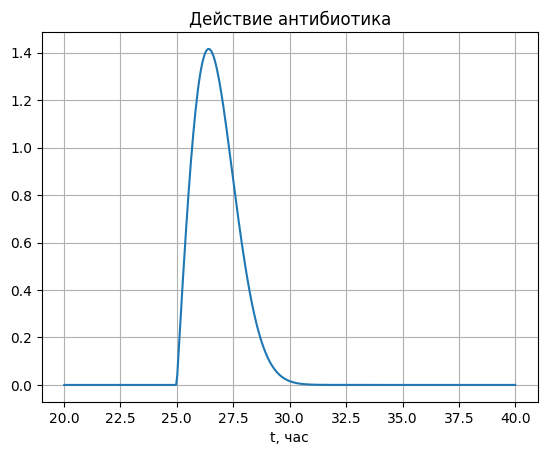

In [93]:
def A(dt):
    A0 = 1.65
    m = 6.6*np.exp(-0.5)
    return A0*dt*np.exp(-dt**2/m)

def H(t):
    return np.where(t > 0, 1, 0)

def f(t):
    k = 0.5
    t0 = 10
    return 0.7 / (1 + np.exp(-k * (t - t0)))

N0, Nmax, r, ts, nu = 7.9793*1e-5, 0.8906, 0.3916, 1, 0.6
tk = [25]
modmod = ModifiedModel(N0, Nmax, r, ts, nu, f, A, tk)
plot_graphs({"Модель": Result(t, modmod.run(t))}, Nmax, "График с модифицированной моделью", "t, час", "N(t), мг/мл")
plt.figure()
plt.plot(t[400:-200], A(t[400:-200] - tk[0]) * H(t[400:-200] - tk[0]))
plt.title('Действие антибиотика')
plt.xlabel('t, час')
plt.ylabel
plt.grid()